In [48]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split
from sklearn import metrics 
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# Data Collection and Processing

In [2]:
excercise_df=pd.read_csv('exercise.csv')

In [3]:
calories_df=pd.read_csv('calories.csv')

In [4]:
excercise_df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [5]:
calories_df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


# Combining Dataframes

In [7]:
calories_data=pd.concat([excercise_df,calories_df['Calories']], axis=1)

In [8]:
calories_data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [9]:
calories_data.shape

(15000, 9)

In [10]:
calories_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

# Data Analysis

In [11]:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [12]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [13]:
sns.set()

<Axes: xlabel='Gender', ylabel='count'>

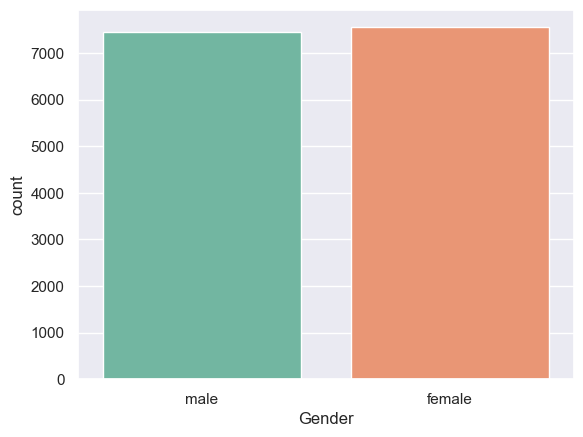

In [23]:
sns.countplot(data=calories_data, x='Gender', palette='Set2', hue='Gender')

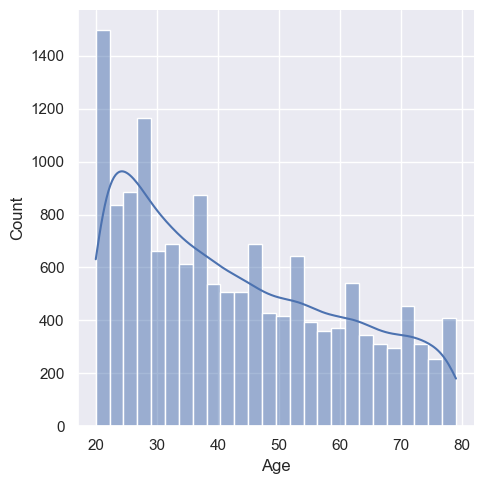

In [20]:
# find distribution of age column
sns.displot(calories_data['Age'], kde=True)

# Encoding Gender

In [28]:
calories_data['Gender']=calories_data['Gender'].map({'male':1,'female':0})

# Correlation

In [29]:
correlation=calories_data.corr()

<Axes: >

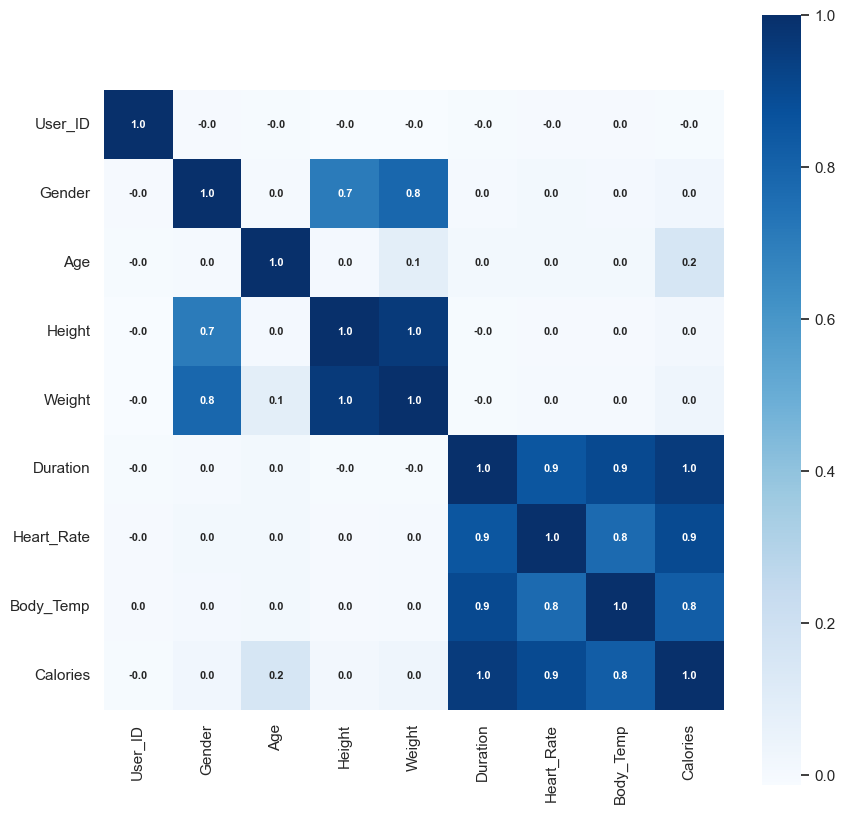

In [34]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8,'weight':'bold'}, cmap='Blues')

# Separating Feature and Target

In [36]:
X=calories_data.drop(columns=['User_ID','Calories'], axis=1)
Y=calories_data['Calories']

# Train Test Split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,Y, test_size=0.2, random_state=42)

# Model Training

In [76]:
model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

In [77]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Prediction on Test Data

In [78]:
test_prediction=model.predict(X_test)

In [79]:
# Mean Absolute Error
mae=metrics.mean_absolute_error(y_test,test_prediction)
print("Mean Absolute Error on Test Data: ", mae)

Mean Absolute Error on Test Data:  1.2241583960056306


In [80]:
#R2  Score 
r2=metrics.r2_score(y_test,test_prediction)
print("R2 Score is ", r2)

R2 Score is  0.9992399914008103


# Prediction on Train Data

In [81]:
train_prediction=model.predict(X_train)

In [82]:
# Mean Absolute Error
mae=metrics.mean_absolute_error(y_train,train_prediction)
print("Mean Absolute Error on Train Data: ", mae)

Mean Absolute Error on Train Data:  0.9566205268971001


In [83]:
r2=metrics.r2_score(y_train,train_prediction)
print("R2 Score is ", r2)

R2 Score is  0.999555476024037


# Predictive System

In [84]:
input=("male,68,190.0,94.0,29.0,105.0,40.8")
data=input.split(',')
data=[np.nan if x=='' else x for x in data]
data_frame=pd.DataFrame([data], columns=X.columns)
data_frame['Gender']=data_frame['Gender'].map({'male':1,'female':0})

for col in data_frame.columns: 
    if data_frame[col].isnull().sum():
        if X[col].dtype==object:
            data_frame[col]=data_frame[col].fillna(X[col].mode()[0])
        else:
            data_frame[col]=data_frame[col].fillna(X[col].mean())
        

data_frame=data_frame.astype(float)

prediction=model.predict(data_frame)
print("Calorie Burnt are ", prediction)

Calorie Burnt are  [233.17213]
